# Makemore Part 1: Bigram Language Model

Karpathy の [makemore](https://github.com/karpathy/makemore) シリーズ第1回。  
**Bigram モデル**（2文字の連鎖）で人名を生成する言語モデルを3段階で実装する。

参考講義: [The spelled-out intro to language modeling: building makemore](https://www.youtube.com/watch?v=PaCmpygFfXo)

## 学習内容
1. **カウントベース** — 出現頻度行列から確率を計算
2. **ニューラルネット（one-hot）** — 線形層 + softmax で同じことを学習
3. **損失評価** — 負の対数尤度（NLL）で品質を測る

## 0. セットアップ

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch version: 2.5.1+cpu
CUDA available: False


## 1. データの読み込みと探索

In [2]:
# 32,032 件の人名データ
words = open('../data/names.txt').read().splitlines()

print(f'Total words: {len(words)}')
print(f'First 10: {words[:10]}')
print(f'Min length: {min(len(w) for w in words)}')
print(f'Max length: {max(len(w) for w in words)}')

Total words: 32033
First 10: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Min length: 2
Max length: 15


## 2. 文字の語彙と特殊トークン

- `'.'` は **開始/終了トークン** (`<S>` と `<E>` を兼ねる)
- 文字 `a-z` + `'.'` で 27 文字

In [3]:
# 文字集合の構築
chars = sorted(set(''.join(words)))
chars = ['.'] + chars  # '.' をインデックス 0 に配置

stoi = {s: i for i, s in enumerate(chars)}  # 文字 → インデックス
itos = {i: s for s, i in stoi.items()}      # インデックス → 文字

vocab_size = len(chars)
print(f'Vocabulary size: {vocab_size}')
print(f'stoi: {stoi}')

Vocabulary size: 27
stoi: {'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


## 3. カウントベース Bigram モデル

### 3.1 Bigram カウント行列の構築

行 = 現在の文字、列 = 次の文字

In [4]:
# 27×27 のカウント行列
N = torch.zeros((vocab_size, vocab_size), dtype=torch.int32)

for w in words:
    chs = ['.'] + list(w) + ['.']  # 開始・終了トークンを付加
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print(f'N shape: {N.shape}')
print(f'N["."]["a"] ("a" から始まる名前の数): {N[0, 1].item()}')

N shape: torch.Size([27, 27])
N["."]["a"] ("a" から始まる名前の数): 4410


### 3.2 Bigram 行列の可視化

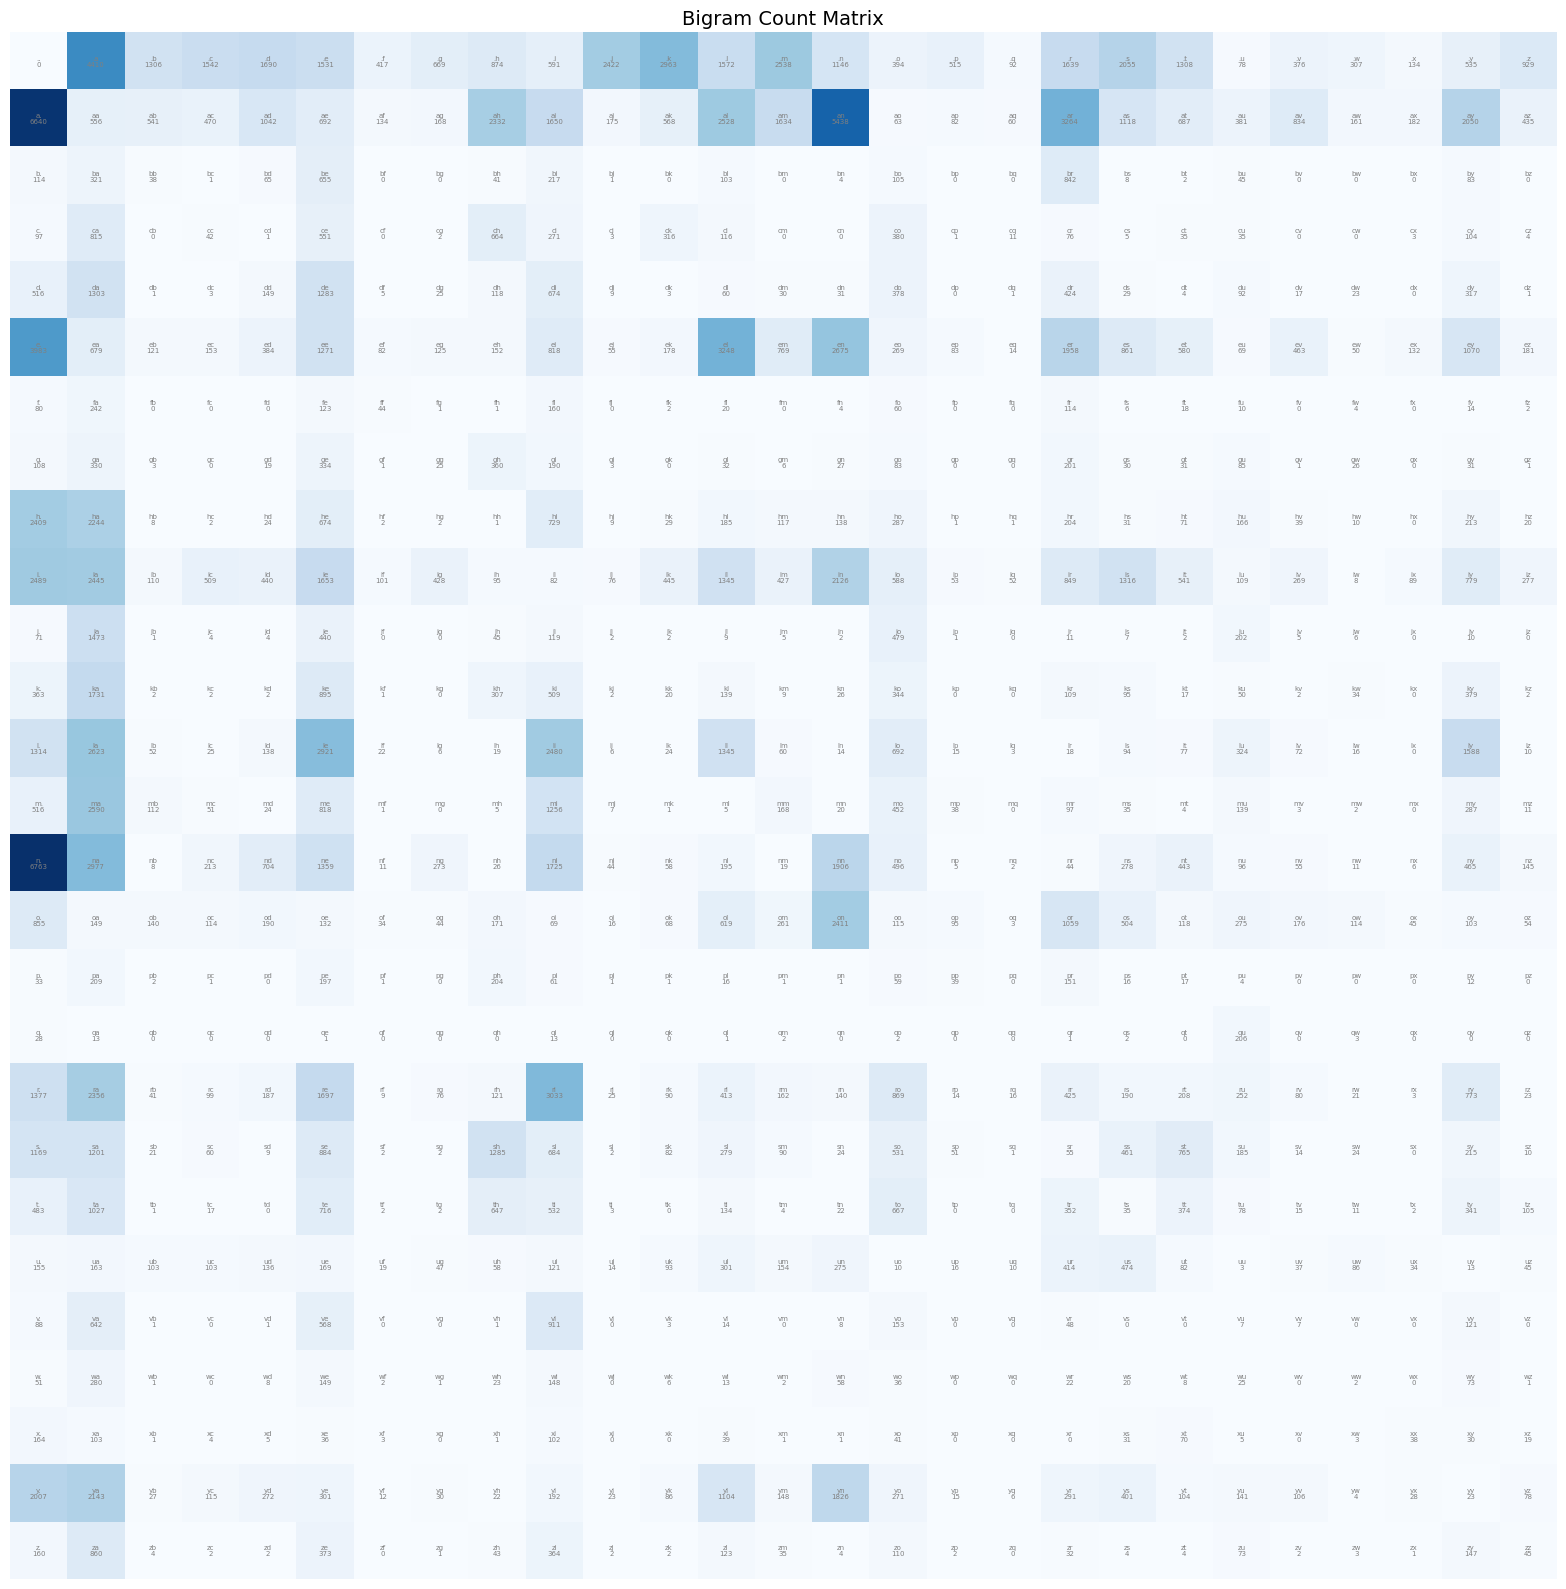

Saved: bigram_counts.png


In [5]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

for i in range(vocab_size):
    for j in range(vocab_size):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray', fontsize=5)
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray', fontsize=5)

plt.axis('off')
plt.title('Bigram Count Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('bigram_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bigram_counts.png')

### 3.3 確率行列への変換（スムージング付き）

**ラプラス・スムージング**: カウントに 1 を加えて「ゼロ確率」を防ぐ

In [6]:
# model_smoothing=1 でスムージング
P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)  # 各行を正規化 → 確率分布

print(f'P shape: {P.shape}')
print(f'Row sum check (should be all 1.0): {P.sum(dim=1)[:5]}')

P shape: torch.Size([27, 27])
Row sum check (should be all 1.0): tensor([1., 1., 1., 1., 1.])


### 3.4 カウントベースモデルでサンプリング

In [7]:
g = torch.Generator().manual_seed(2147483647)

def sample_from_model(P, itos, g, num_samples=10):
    """確率行列 P からサンプリングして名前を生成する"""
    results = []
    for _ in range(num_samples):
        name = []
        ix = 0  # '.' (開始)
        while True:
            p = P[ix]  # 現在の文字の確率分布
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            if ix == 0:  # '.' (終了)
                break
            name.append(itos[ix])
        results.append(''.join(name))
    return results

samples = sample_from_model(P, itos, g)
print('Generated names (count-based model):')
for name in samples:
    print(f'  {name}')

Generated names (count-based model):
  junide
  janasah
  p
  cony
  a
  nn
  kohin
  tolian
  juee
  ksahnaauranilevias


### 3.5 負の対数尤度（NLL）損失

$$
\text{NLL} = -\frac{1}{N}\sum_{i} \log P(c_{i+1} \mid c_i)
$$

完璧なモデルなら NLL → 0。ランダムモデルなら `log(1/27) ≈ 3.29`

In [8]:
log_likelihood = 0.0
n_bigrams = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        log_likelihood += torch.log(prob).item()
        n_bigrams += 1

nll = -log_likelihood / n_bigrams
print(f'Total bigrams: {n_bigrams}')
print(f'Log likelihood: {log_likelihood:.2f}')
print(f'NLL (count-based, smoothed): {nll:.4f}')
print(f'\nRandom baseline (uniform): {torch.log(torch.tensor(1/27)).neg().item():.4f}')

Total bigrams: 228146
Log likelihood: -560001.88
NLL (count-based, smoothed): 2.4546

Random baseline (uniform): 3.2958


---
## 4. ニューラルネット Bigram モデル

カウントベースと**数学的に等価**だが、勾配降下法で学習する。

$$
\text{logits} = x W, \quad \hat{y} = \text{softmax}(\text{logits})
$$

- $x$: one-hot エンコード（形状: `[N, 27]`）
- $W$: 重み行列（形状: `[27, 27]`）— これが学習パラメータ

### 4.1 学習データセットの構築

In [9]:
# (入力文字, 次の文字) のペアを全データから収集
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num_examples = xs.nelement()
print(f'Number of training examples: {num_examples}')
print(f'xs[:5] = {xs[:5]}  →  {[itos[i.item()] for i in xs[:5]]}')
print(f'ys[:5] = {ys[:5]}  →  {[itos[i.item()] for i in ys[:5]]}')

Number of training examples: 228146
xs[:5] = tensor([ 0,  5, 13, 13,  1])  →  ['.', 'e', 'm', 'm', 'a']
ys[:5] = tensor([ 5, 13, 13,  1,  0])  →  ['e', 'm', 'm', 'a', '.']


### 4.2 モデルパラメータの初期化

In [10]:
g = torch.Generator().manual_seed(2147483647)

# 27×27 の重み行列（ランダム初期化）
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

print(f'W shape: {W.shape}')
print(f'W requires_grad: {W.requires_grad}')

W shape: torch.Size([27, 27])
W requires_grad: True


### 4.3 フォワードパスの解説

In [11]:
# フォワードパスのステップを1件ずつ確認
with torch.no_grad():
    # Step 1: one-hot エンコード
    xenc = F.one_hot(xs[:5], num_classes=vocab_size).float()
    print(f'one-hot shape: {xenc.shape}')  # [5, 27]

    # Step 2: 線形変換 → logits
    logits = xenc @ W
    print(f'logits shape: {logits.shape}')  # [5, 27]

    # Step 3: softmax → 確率
    counts = logits.exp()
    probs = counts / counts.sum(dim=1, keepdim=True)
    print(f'probs shape: {probs.shape}')
    print(f'probs row sum: {probs.sum(dim=1)}')

    # Step 4: NLL 損失
    nll_demo = -probs[torch.arange(5), ys[:5]].log().mean()
    print(f'NLL (first 5, before training): {nll_demo.item():.4f}')

one-hot shape: torch.Size([5, 27])
logits shape: torch.Size([5, 27])
probs shape: torch.Size([5, 27])
probs row sum: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
NLL (first 5, before training): 3.7693


### 4.4 訓練ループ

In [12]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((vocab_size, vocab_size), generator=g, requires_grad=True)

losses = []
n_epochs = 200
lr = 50.0  # 全バッチ学習では大きな LR でも安定する

for epoch in range(n_epochs):
    # ---- Forward pass ----
    xenc = F.one_hot(xs, num_classes=vocab_size).float()  # [N, 27]
    logits = xenc @ W                                      # [N, 27]

    # softmax + NLL を F.cross_entropy でまとめて計算（数値安定）
    loss = F.cross_entropy(logits, ys)

    losses.append(loss.item())

    # ---- Backward pass ----
    W.grad = None          # 勾配リセット（zero_grad 相当）
    loss.backward()

    # ---- Update ----
    with torch.no_grad():
        W -= lr * W.grad

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs}  loss={loss.item():.4f}')

print(f'\nFinal NLL loss: {losses[-1]:.4f}')

Epoch  20/200  loss=2.5794
Epoch  40/200  loss=2.5103
Epoch  60/200  loss=2.4887
Epoch  80/200  loss=2.4787
Epoch 100/200  loss=2.4729
Epoch 120/200  loss=2.4692
Epoch 140/200  loss=2.4667
Epoch 160/200  loss=2.4648
Epoch 180/200  loss=2.4635
Epoch 200/200  loss=2.4624

Final NLL loss: 2.4624


### 4.5 損失曲線のプロット

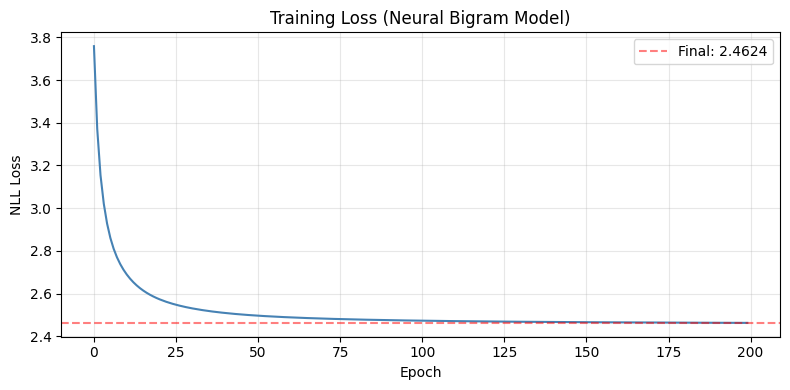

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('NLL Loss')
plt.title('Training Loss (Neural Bigram Model)')
plt.grid(alpha=0.3)
plt.axhline(y=losses[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

### 4.6 学習済みモデルでサンプリング

In [14]:
g = torch.Generator().manual_seed(2147483647)

def sample_nn(W, itos, g, num_samples=10):
    """学習済み重み行列 W からサンプリング"""
    results = []
    for _ in range(num_samples):
        name = []
        ix = 0
        while True:
            xenc = F.one_hot(torch.tensor([ix]), num_classes=vocab_size).float()
            logits = xenc @ W
            p = F.softmax(logits, dim=1)
            ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            if ix == 0:
                break
            name.append(itos[ix])
        results.append(''.join(name))
    return results

with torch.no_grad():
    samples_nn = sample_nn(W, itos, g)

print('Generated names (neural bigram model):')
for name in samples_nn:
    print(f'  {name}')

Generated names (neural bigram model):
  junide
  janasah
  prelay
  a
  nn
  kohin
  tolian
  juee
  ksahnaauranilevias
  dedainrwieta


---
## 5. カウントベース vs ニューラルネット の比較

**なぜ同じ結果になるのか？**

| 項目 | カウントベース | ニューラルネット |
|------|---------------|----------------|
| パラメータ | カウント行列 N | 重み行列 W |
| 確率計算 | `N[i] / N[i].sum()` | `softmax(x @ W)` |
| 最適化 | 閉形式（解析解） | 勾配降下法 |
| 最終 NLL | 同じ値に収束 | 同じ値に収束 |

`log(N+1)` ≈ `W` の収束値（スムージングは正則化に相当）

In [15]:
# 両者の最終 NLL を比較
# カウントベース NLL（再計算）
log_likelihood = 0.0
n_bigrams = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        log_likelihood += torch.log(P[ix1, ix2]).item()
        n_bigrams += 1
nll_count = -log_likelihood / n_bigrams

# ニューラルネット NLL
with torch.no_grad():
    xenc = F.one_hot(xs, num_classes=vocab_size).float()
    logits = xenc @ W
    nll_nn = F.cross_entropy(logits, ys).item()

print(f'Count-based NLL (smoothed): {nll_count:.4f}')
print(f'Neural net NLL (trained):   {nll_nn:.4f}')
print(f'Difference: {abs(nll_count - nll_nn):.6f}')
print()
print('両者はほぼ同じ値に収束する（理論的に等価）')

Count-based NLL (smoothed): 2.4546
Neural net NLL (trained):   2.4623
Difference: 0.007769

両者はほぼ同じ値に収束する（理論的に等価）


## 6. W の可視化

学習済みの W と log(P) を比較する

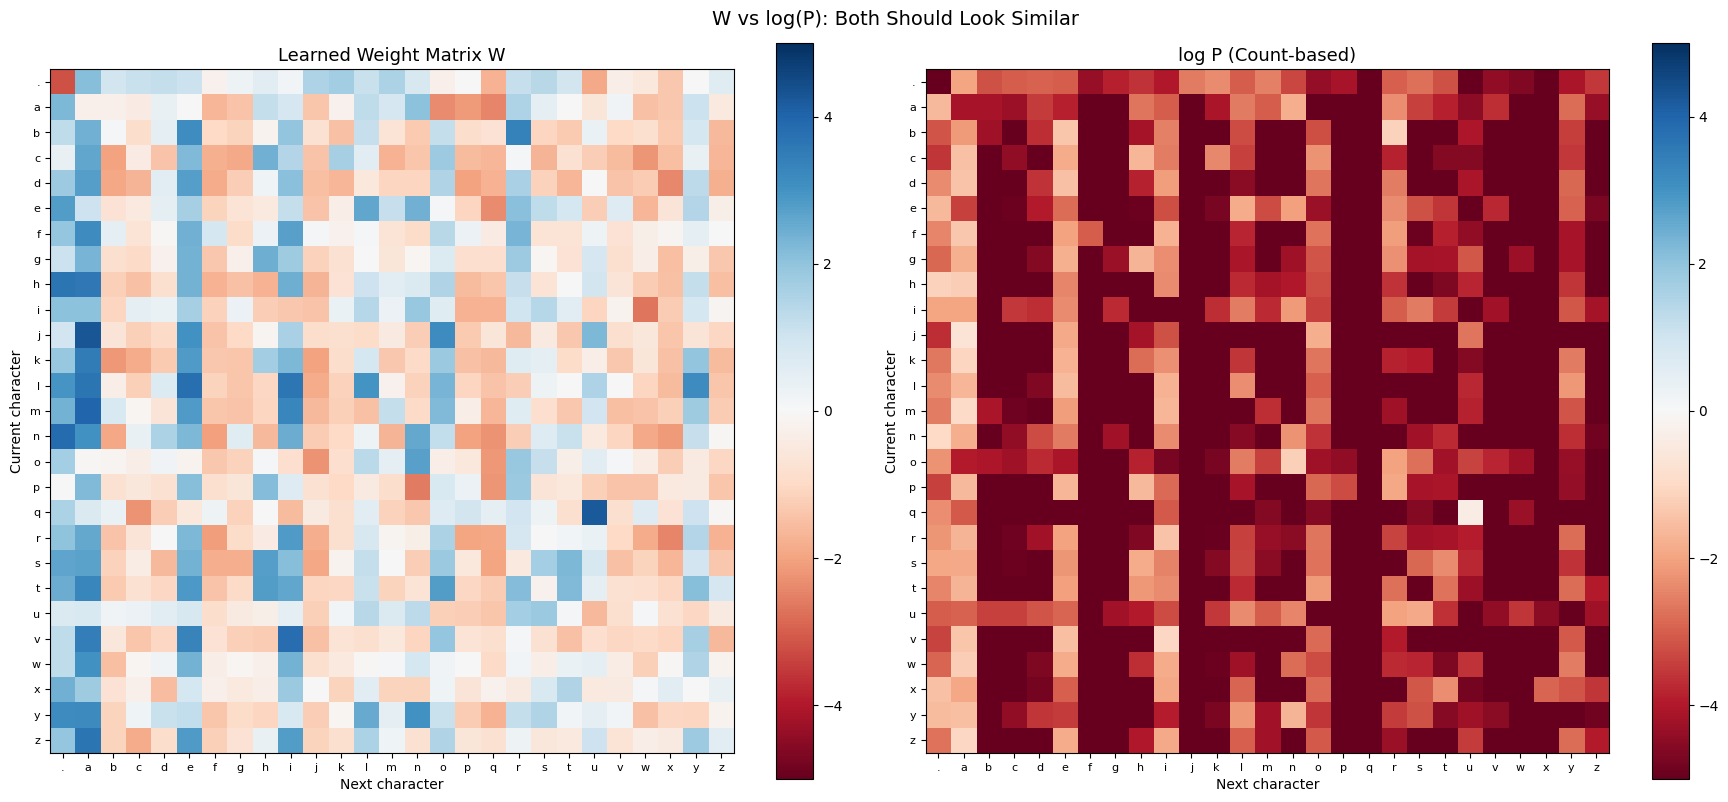

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 学習済み W
ax = axes[0]
im = ax.imshow(W.detach(), cmap='RdBu', vmin=-5, vmax=5)
ax.set_title('Learned Weight Matrix W', fontsize=13)
ax.set_xticks(range(vocab_size))
ax.set_yticks(range(vocab_size))
ax.set_xticklabels([itos[i] for i in range(vocab_size)], fontsize=8)
ax.set_yticklabels([itos[i] for i in range(vocab_size)], fontsize=8)
ax.set_xlabel('Next character')
ax.set_ylabel('Current character')
plt.colorbar(im, ax=ax)

# log(P) カウントベース
ax = axes[1]
log_P = torch.log(P)
im2 = ax.imshow(log_P, cmap='RdBu', vmin=-5, vmax=5)
ax.set_title('log P (Count-based)', fontsize=13)
ax.set_xticks(range(vocab_size))
ax.set_yticks(range(vocab_size))
ax.set_xticklabels([itos[i] for i in range(vocab_size)], fontsize=8)
ax.set_yticklabels([itos[i] for i in range(vocab_size)], fontsize=8)
ax.set_xlabel('Next character')
ax.set_ylabel('Current character')
plt.colorbar(im2, ax=ax)

plt.suptitle('W vs log(P): Both Should Look Similar', fontsize=14)
plt.tight_layout()
plt.savefig('W_vs_logP.png', dpi=150)
plt.show()

---
## 7. まとめと次のステップ

### Key Takeaways

| # | ポイント |
|---|----------|
| 1 | **Bigram = 直前の1文字のみ参照**するマルコフ連鎖モデル |
| 2 | カウントベースは**解析的に最適解**を求める（閉形式）|
| 3 | ニューラルネットは**勾配降下法**で同じ答えに収束する |
| 4 | `softmax(x @ W)` = 線形モデルの基本形。次回はこれを**多層化**する |
| 5 | NLL は言語モデルの標準的な損失関数。`cross_entropy = log_softmax + nll` |

### 次回: `03_makemore_mlp`
- **MLP（多層パーセプトロン）**で前 N 文字を参照する
- Bengio 2003 論文の実装
- 埋め込み層（Embedding）の導入